# A2 — Reconhecimento semântico em publicidade visual com CLIP (ADS-16)

**Disciplina:** Visão Computacional com CNNs e Transformers [26E3_3] — INFNET · **Aluno:** Lucas de Oliveira Ferreira

**Objetivo:** extrair inteligência semântica do corpus de imagens do ADS-16 **sem treinar nenhum modelo** — só embeddings pré-treinados do CLIP e consultas em linguagem natural: (2.1) ranking dos objetos/conceitos mais presentes e (2.2) busca de imagens por texto.

**Dataset:** [ADS-16 Computational Advertising Dataset](https://www.kaggle.com/datasets/groffo/ads16-dataset) (Roffo & Vinciarelli, 2016).

| Requisito | Valor estimado (Colab T4) |
|---|---|
| GPU | T4 — < 2 GB de VRAM (CLIP ViT-B/32 em fp16, só inferência) |
| RAM | ~3 GB |
| Disco | ~3 GB temporários (zip de 1,6 GB + extração ~0,8 GB; o zip pode ser apagado) |
| Tempo total | ~5–8 min no T4 (download ~2 min, extração ~1 min, embeddings < 1 min, análises ~1 min) — **medido: 2,2 min** numa RTX 3050 6 GB, sem contar o download |

**Como rodar:** T4 GPU → `Executar tudo`. Sem Drive e sem `kaggle.json`.

**Uso de IA:** código e texto elaborados com apoio do Claude (Anthropic), revisados e executados pelo aluno; números e figuras são outputs reais deste notebook.

**Base nas aulas:** Aula 06 (CLIP: duas torres, normalização L2, zero-shot, *prompt ensembling*, busca com `torch.topk`, pacote `clip` da OpenAI), Aula 08 (cosseno não é probabilidade; faixas de ruído/alinhamento; calibração de τ pelo percentil 95 de pares negativos; variar o threshold nas consultas).

> **Aviso de conteúdo:** parte do corpus são fotos que os participantes marcaram como "negativas" (imagens que os repulsam); algumas podem aparecer nos exemplos recuperados.

## 0. Setup

In [1]:
import os, sys, subprocess, time, json, random, hashlib, zipfile, shutil, urllib.request
from pathlib import Path
from collections import Counter

try:
    import clip
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ftfy", "regex", "git+https://github.com/openai/CLIP.git"], check=True)
    import clip

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch

IN_COLAB = "google.colab" in sys.modules
DATA_ROOT = Path(os.environ.get("DATA_ROOT", "/content/data" if IN_COLAB else "data")).resolve()
FIG_DIR = Path(os.environ.get("FIG_DIR", "figs/A2")).resolve(); FIG_DIR.mkdir(parents=True, exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
Image.MAX_IMAGE_PIXELS = None

def savefig(name):
    plt.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

print("torch", torch.__version__, "| device", DEVICE, "| CLIP models:", clip.available_models())

torch 2.14.1+cu126 | device cuda | CLIP models: ['RN50', 'RN101', 'RN50x4', 'RN50x16', 'RN50x64', 'ViT-B/32', 'ViT-B/16', 'ViT-L/14', 'ViT-L/14@336px']


## 1. Download e montagem do corpus

O pacote do Kaggle traz o benchmark em duas partes (`part1`, `part2`), cada uma com as pastas extraídas **e** cópias zipadas (`Ads.zip`, `Corpus.zip`). Extraímos só as pastas de imagens e o PDF do artigo (que contém os nomes das categorias); os `.zip` internos são duplicatas e são ignorados.

In [2]:
class Archive:
    def __init__(self, path):
        self.path = Path(path); self.zf = zipfile.ZipFile(self.path) if self.path.is_file() else None
    def names(self):
        if self.zf: return [n for n in self.zf.namelist() if not n.endswith("/")]
        return [p.relative_to(self.path).as_posix() for p in self.path.rglob("*") if p.is_file()]
    def extract(self, name, dest_root):
        out = Path(dest_root) / name; out.parent.mkdir(parents=True, exist_ok=True)
        if self.zf:
            with self.zf.open(name) as s, open(out, "wb") as d: shutil.copyfileobj(s, d)
        else: shutil.copy(self.path / name, out)

def kaggle_archive(ref, name):
    zpath = DATA_ROOT / "_zips" / f"{name}.zip"
    if zpath.exists(): return Archive(zpath)
    zpath.parent.mkdir(parents=True, exist_ok=True)
    try:
        with urllib.request.urlopen(f"https://www.kaggle.com/api/v1/datasets/download/{ref}", timeout=900) as r, \
             open(f"{zpath}.part", "wb") as f:
            shutil.copyfileobj(r, f, 1 << 20)
        os.replace(f"{zpath}.part", zpath); return Archive(zpath)
    except Exception as e:
        print("Download anônimo falhou:", e, "→ kagglehub"); import kagglehub
        return Archive(kagglehub.dataset_download(ref))

ADS_DIR = DATA_ROOT / "ads16"
if not ADS_DIR.exists():
    arc = kaggle_archive("groffo/ads16-dataset", "ads16")
    for n in arc.names():
        if not n.endswith(".zip") and ("/Ads/Ads/" in n or "/Corpus/Corpus/" in n or n.endswith(".pdf")):
            arc.extract(n, ADS_DIR)

# Nomes das 20 categorias (Tabela 1 do artigo que acompanha o dataset: Roffo & Vinciarelli, 2016)
CATEGORIES = {1: "Clothing & Shoes", 2: "Automotive", 3: "Baby", 4: "Health & Beauty", 5: "Media",
              6: "Consumer Electronics", 7: "Console & Video Games", 8: "Tools & Hardware", 9: "Outdoor Living",
              10: "Grocery", 11: "Home", 12: "Betting", 13: "Jewelery & Watches", 14: "Musical instruments",
              15: "Stationery & Office Supplies", 16: "Pet Supplies", 17: "Computer Software", 18: "Sports",
              19: "Toys & Games", 20: "Social Dating Sites"}

IMG_EXT = {".png", ".jpg", ".jpeg", ".gif", ".bmp"}
rows = []
for p in sorted(ADS_DIR.rglob("*")):
    if p.suffix.lower() not in IMG_EXT: continue
    parts = p.as_posix().split("/")
    if "Ads" in parts:
        cat = int(parts[-2]); rows.append(dict(path=str(p), origem="anúncio", categoria=CATEGORIES[cat], cat_id=cat, usuario=None))
    elif "Corpus" in parts:
        if "_th_" in p.name:      # miniatura (thumbnail) da mesma foto: "1_th_1445340278.png" duplica "1.png"
            continue
        polar = "foto_positiva" if parts[-2].endswith("IM-POS") else "foto_negativa"
        rows.append(dict(path=str(p), origem=polar, categoria=None, cat_id=None, usuario=parts[-3]))
corpus = pd.DataFrame(rows)
corpus["md5"] = corpus.path.map(lambda f: hashlib.md5(Path(f).read_bytes()).hexdigest())
n_raw = len(corpus)
corpus = corpus.drop_duplicates("md5").reset_index(drop=True)

# Legendas livres que cada participante escreveu para as próprias fotos (arquivos U####-IM-POS.csv / -IM-NEG.csv:
# linha 2 = caminho da imagem, linha 3 = descrição). Servem de pares imagem–texto reais para calibrar o threshold.
import csv
tags = {}
for f in ADS_DIR.rglob("*-IM-*.csv"):
    with open(f, encoding="utf-8", errors="replace", newline="") as fh:
        r = list(csv.reader(fh, delimiter=";"))
    if len(r) >= 3:
        # A coluna k descreve a imagem "{k}.png" da pasta homônima do CSV. Associamos pela posição, porque em alguns
        # usuários a linha de caminhos do CSV foi copiada de outro participante (ex.: U0100 aponta para "U0050-IM-POS/...").
        for k, tag in enumerate(r[2], start=1):
            tags[(f.parent / f.stem / f"{k}.png").resolve().as_posix().lower()] = tag.strip()
corpus["legenda"] = corpus.path.map(lambda p: tags.get(Path(p).resolve().as_posix().lower()))
print(f"imagens encontradas: {n_raw} | após remover duplicatas exatas (MD5): {len(corpus)} | fotos com legenda do participante: {corpus.legenda.notna().sum()}")
print("exemplos de legendas:", corpus.legenda.dropna().sample(8, random_state=0).tolist())
corpus.origem.value_counts()

imagens encontradas: 1524 | após remover duplicatas exatas (MD5): 1501 | fotos com legenda do participante: 1196
exemplos de legendas: ['mayo, yuck', 'injury hurt', 'Untrustworthym', 'nicaragua nature beauty', 'anxiety', 'SubwayDelays', 'munchkin', 'phone, Sony, Xperia, Z1']


origem
foto_positiva    611
foto_negativa    589
anúncio          301
Name: count, dtype: int64

### O que é o corpus — e uma divergência com o enunciado

- **Anúncios:** 300 anúncios reais (texto, imagem e *rich media*) em **20 categorias de produto/serviço, 15 por categoria** — e não 16 categorias, como diz o enunciado. Os nomes das categorias vêm da Tabela 1 do artigo original.
- **Fotos dos participantes:** ~1.200 fotos que os 120 participantes enviaram como algo de que gostam (**positivas**) ou que os repulsam (**negativas**), cada uma com uma legenda escrita pelo próprio participante. Fazem parte do corpus do ADS-16 porque o benchmark estuda a relação entre preferências visuais dos consumidores e anúncios. Cada foto aparece no pacote **duas vezes** — o original (`3.png`) e uma miniatura (`3_th_<timestamp>.png`) com bytes diferentes, que a deduplicação por MD5 não detecta; as miniaturas são descartadas para não contar a mesma imagem duas vezes no ranking.

**Decisão:** usamos **o corpus completo** (anúncios + fotos), o que atende "corpus do ADS-16 ou subconjunto de ≥ 500 imagens" sem precisar de amostragem — e com 300 anúncios apenas, nenhum subconjunto só de anúncios chegaria a 500. Como as duas origens têm naturezas diferentes, **todas as análises são reportadas também separadas por origem**.

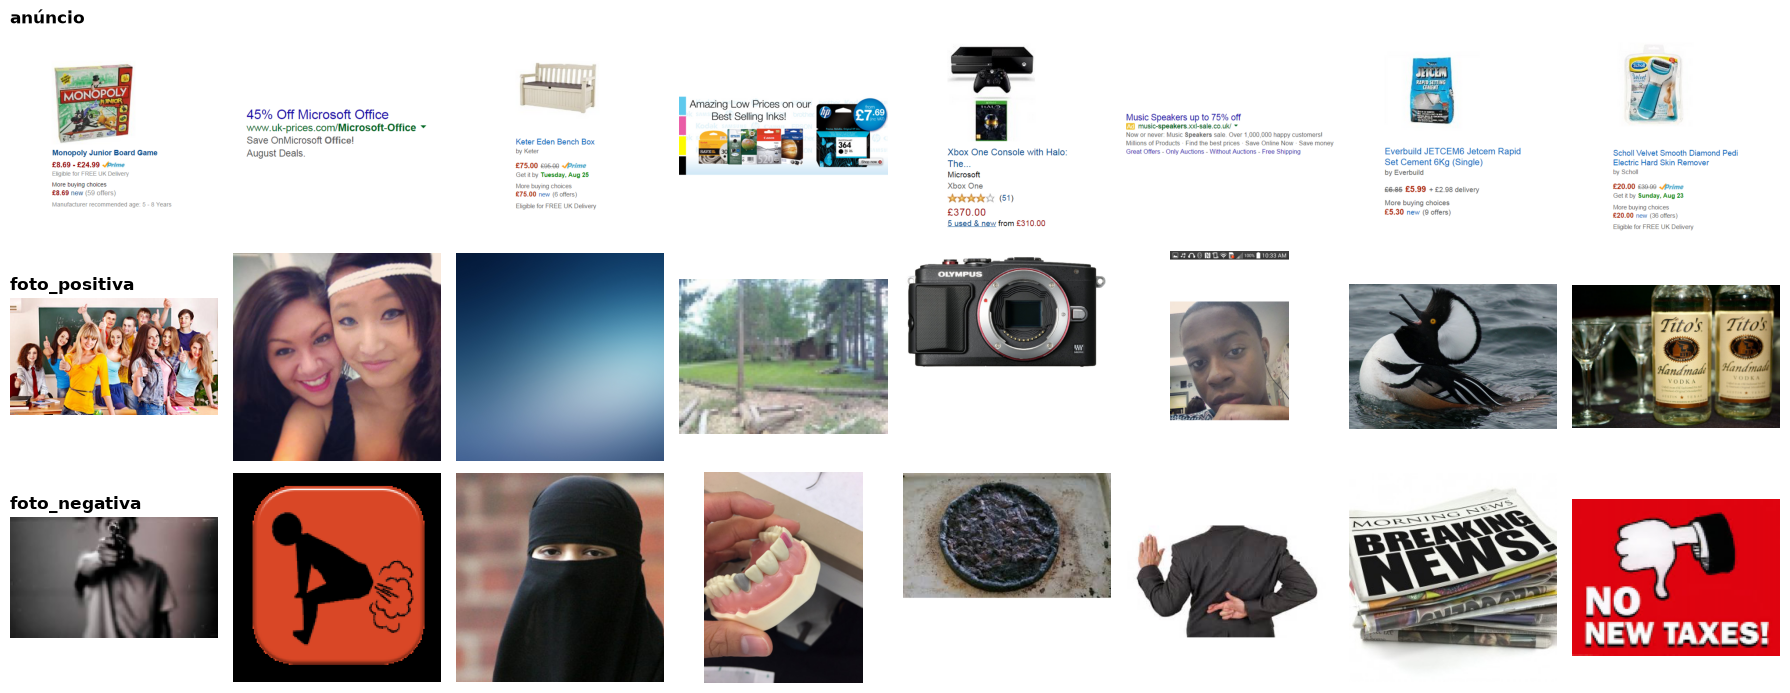

In [3]:
fig, axes = plt.subplots(3, 8, figsize=(18, 7))
for i, o in enumerate(["anúncio", "foto_positiva", "foto_negativa"]):
    for j, p in enumerate(corpus[corpus.origem == o].sample(8, random_state=1).path):
        im = Image.open(p); im = im.convert("RGBA") if im.mode in ("P", "LA") else im
        axes[i, j].imshow(im.convert("RGB")); axes[i, j].axis("off")
    axes[i, 0].set_title(o, loc="left", fontweight="bold")
plt.tight_layout(); savefig("01_amostra_corpus"); plt.show()

## 2. Embeddings de imagem com CLIP ViT-B/32

**Por que CLIP ViT-B/32:** é o modelo usado nas Aulas 06/08 e no notebook de referência da disciplina; espaço conjunto imagem–texto de 512 dimensões, pré-treinado em 400 M pares (WIT). É leve (cabe com folga no T4) e suficiente para conceitos de nível de objeto/cena.

Cada imagem passa pelo pré-processamento do CLIP (resize 224 + center crop + normalização do CLIP) e o vetor é **normalizado em L2**: assim o produto escalar entre imagem e texto é exatamente a *cosine similarity* (Aula 06). Imagens com transparência são compostas sobre fundo branco (como seriam exibidas numa página).

In [4]:
model, preprocess = clip.load("ViT-B/32", device=DEVICE)
model.eval()

def load_rgb(p):
    im = Image.open(p)
    if im.mode in ("P", "LA", "RGBA"):
        im = im.convert("RGBA"); bg = Image.new("RGBA", im.size, (255, 255, 255, 255)); im = Image.alpha_composite(bg, im)
    return im.convert("RGB")

@torch.no_grad()
def encode_images(paths, bs=128):
    out = []
    for i in range(0, len(paths), bs):
        x = torch.stack([preprocess(load_rgb(p)) for p in paths[i:i + bs]]).to(DEVICE)
        f = model.encode_image(x).float()
        out.append((f / f.norm(dim=-1, keepdim=True)).cpu())
    return torch.cat(out)

@torch.no_grad()
def encode_texts(texts):
    f = model.encode_text(clip.tokenize(texts).to(DEVICE)).float()
    return (f / f.norm(dim=-1, keepdim=True)).cpu()

def encode_concepts(concepts, templates):
    """Prompt ensembling (Aula 06): média dos embeddings de vários templates, renormalizada."""
    embs = []
    for c in concepts:
        e = encode_texts([t.format(c) for t in templates]).mean(0)
        embs.append(e / e.norm())
    return torch.stack(embs)

cache = DATA_ROOT / "ads16_clip_vitb32.pt"
t0 = time.time()
if cache.exists() and torch.load(cache)["md5"] == corpus.md5.tolist():
    IMG = torch.load(cache)["emb"]
else:
    IMG = encode_images(corpus.path.tolist()); torch.save({"md5": corpus.md5.tolist(), "emb": IMG}, cache)
print("embeddings:", tuple(IMG.shape), f"| {time.time()-t0:.0f}s | normas ≈ 1:", IMG.norm(dim=1)[:3].numpy().round(4))

.\.venv\Lib\site-packages\torch\jit\_serialization.py:176: FutureWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(


embeddings: (1501, 512) | 0s | normas ≈ 1: [1. 1. 1.]


### Sanidade: classificação zero-shot das 20 categorias de anúncio

Antes de confiar no espaço de embeddings, testamos se ele "entende" este corpus: classificamos cada anúncio em uma das 20 categorias **zero-shot** (sem treino), comparando a imagem com o texto de cada categoria (Aula 06). Isso também gera os pares positivos/negativos que usaremos para calibrar o threshold.

~\AppData\Local\Temp\ipykernel_132\749707274.py:5: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  S_cat = IMG[ads_mask] @ CAT_TXT.T                                    # [300, 20] cosine similarity


zero-shot nas 20 categorias: top-1 = 0.598 | top-3 = 0.767 | acaso = 0.050


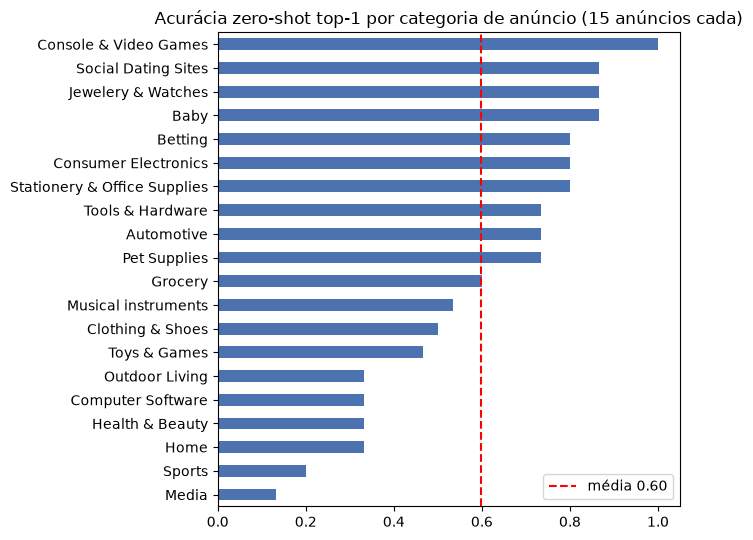

In [5]:
CAT_TEMPLATES = ["an advertisement for {}.", "an online ad about {}.", "a banner ad selling {}.", "a product ad in the category {}."]
cat_names = [CATEGORIES[i] for i in range(1, 21)]
CAT_TXT = encode_concepts([c.lower().replace("&", "and") for c in cat_names], CAT_TEMPLATES)
ads_mask = (corpus.origem == "anúncio").values
S_cat = IMG[ads_mask] @ CAT_TXT.T                                    # [300, 20] cosine similarity
y_cat = corpus.loc[ads_mask, "cat_id"].values.astype(int) - 1
top1 = (S_cat.argmax(1).numpy() == y_cat).mean()
top3 = np.mean([y in row for y, row in zip(y_cat, S_cat.topk(3, dim=1).indices.numpy())])
print(f"zero-shot nas 20 categorias: top-1 = {top1:.3f} | top-3 = {top3:.3f} | acaso = {1/20:.3f}")
per_cat = pd.Series([(S_cat[y_cat == k].argmax(1).numpy() == k).mean() for k in range(20)], index=cat_names).sort_values()
per_cat.plot.barh(figsize=(7, 5.5), color="#4C72B0"); plt.axvline(top1, color="red", ls="--", label=f"média {top1:.2f}")
plt.title("Acurácia zero-shot top-1 por categoria de anúncio (15 anúncios cada)"); plt.legend(); plt.tight_layout(); savefig("02_zero_shot_categorias"); plt.show()

## 3. Item 2.1 — Ranking de objetos por frequência semântica

### 3.1 Vocabulário de 24 conceitos

Os conceitos cobrem o que tipicamente aparece em publicidade e em fotos pessoais: pessoas, produtos de consumo, veículos e tecnologia, cenários, animais, dinheiro e elementos gráficos de anúncio. Cada conceito é descrito por **4 templates** e os embeddings são médios (*prompt ensembling*), o que reduz a sensibilidade a uma redação específica (Aula 06: ensemble > template único > palavra solta).

In [6]:
CONCEPTS = ["a person", "a woman", "a man", "a child", "food", "a drink or beverage", "a bottle", "clothing",
            "shoes", "jewelry or a watch", "cosmetics or makeup", "a car", "a smartphone or electronic device", "a computer",
            "a building or city street", "outdoor nature scenery", "a beach", "a home interior with furniture", "an animal",
            "people playing sports", "money or a credit card", "an airplane", "text and a logo", "a product on a plain white background"]
TEMPLATES = ["a photo of {}.", "an image showing {}.", "a picture containing {}.", "an advertisement featuring {}."]
C_TXT = encode_concepts(CONCEPTS, TEMPLATES)
S = (IMG @ C_TXT.T).numpy()                                          # [N, 24] cosine similarity imagem × conceito
print("matriz de similaridade:", S.shape, "| min %.3f  mediana %.3f  max %.3f" % (S.min(), np.median(S), S.max()))

matriz de similaridade: (1501, 24) | min 0.071  mediana 0.197  max 0.314


### 3.2 Threshold: quando dizer que um conceito "está presente"

A *cosine similarity* do CLIP **não é probabilidade** e vive numa faixa estreita: ruído de fundo ~0,12–0,22, alinhamento fraco ~0,20–0,24, forte ≥ 0,28 (Aula 08). Um threshold arbitrário não serve — definimos o τ **por calibração empírica neste corpus**, como recomendado na Aula 08: **percentil 95 de pares negativos aleatórios**.

- **De onde vêm os pares imagem–texto:** cada participante descreveu com as próprias palavras as fotos que enviou ("my cats", "pizza", "seafood fish"...). São ~2.300 pares imagem–legenda **reais e escritos por humanos**, sobre conteúdo variado — o equivalente, neste corpus, às legendas da Aula 08.
- **Positivos:** cada foto com a **sua** legenda. **Negativos aleatórios:** cada foto com a legenda de **outra** foto (excluindo legendas idênticas). As legendas recebem os **mesmos 4 templates** dos conceitos, para que as escalas de similaridade sejam comparáveis.
- **τ = percentil 95 dos negativos:** um par imagem–conceito conta como "presente" se a similaridade supera 95% das similaridades de pares que **não** correspondem — taxa de falso positivo esperada de ~5% por par. (Legendas semanticamente iguais mas escritas de forma diferente — "pizza" de dois usuários — entram como "negativos", o que torna o τ levemente conservador.)

**Uma calibração que não funciona — e por quê.** A primeira tentativa usou os anúncios contra as 19 categorias **erradas** ("an advertisement for {categoria}"). O τ resultante é alto demais para os conceitos: todo prompt do tipo "an advertisement for…" compartilha com **qualquer** anúncio o componente semântico "isto é um anúncio", o que infla também os pares negativos. O threshold herda essa inflação e, aplicado aos conceitos (que não têm esse componente), quase nada passa. Mostramos as duas distribuições lado a lado.

pares positivos (foto × própria legenda): n=1183 mediana=0.281
pares negativos aleatórios (foto × legenda de outra foto): n=1,398,198 mediana=0.191
τ = P95 dos negativos = 0.2337 | positivos acima de τ: 87.4%
[comparação] calibração por categoria de anúncio: P95 negativos = 0.2745 (mediana dos negativos 0.238)


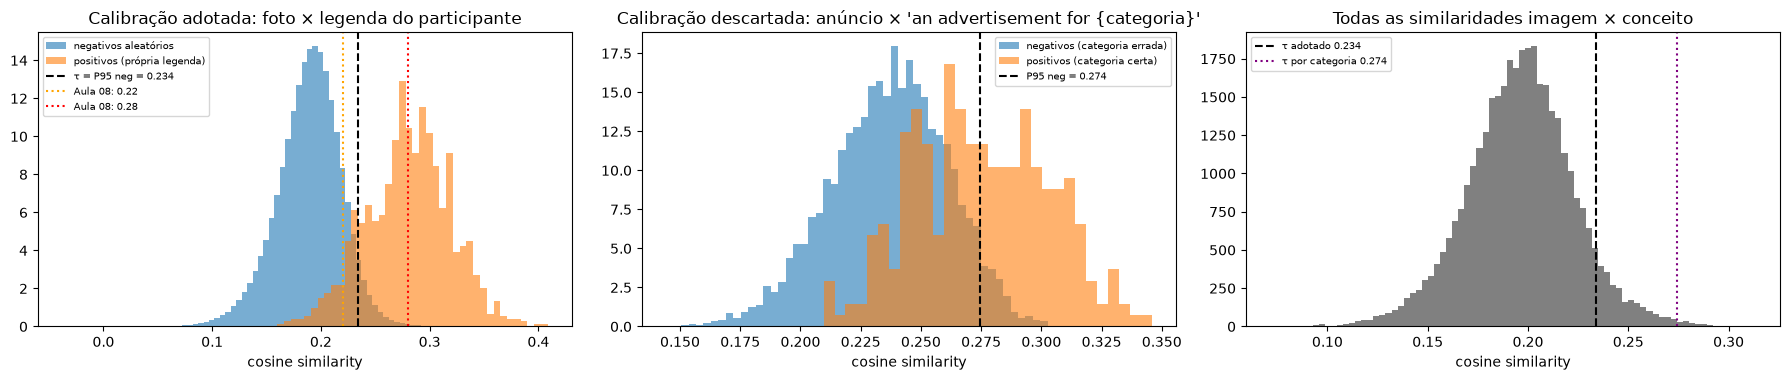

In [7]:
lab = corpus.legenda.fillna("").str.strip()
tagged = np.where(lab.str.len() > 1)[0]
L_TXT = encode_concepts(lab.iloc[tagged].tolist(), TEMPLATES)
S_tag = (IMG[tagged] @ L_TXT.T).numpy()                              # [n, n]: foto i × legenda j
lab_arr = lab.iloc[tagged].str.lower().to_numpy(dtype=object)
same_text = lab_arr[:, None] == lab_arr[None, :]
pos = np.diag(S_tag)
neg = S_tag[~same_text]
TAU = float(np.percentile(neg, 95))
print(f"pares positivos (foto × própria legenda): n={len(pos)} mediana={np.median(pos):.3f}")
print(f"pares negativos aleatórios (foto × legenda de outra foto): n={len(neg):,} mediana={np.median(neg):.3f}")
print(f"τ = P95 dos negativos = {TAU:.4f} | positivos acima de τ: {(pos >= TAU).mean():.1%}")

S_cat_np = S_cat.numpy()
pos_cat = S_cat_np[np.arange(len(y_cat)), y_cat]
neg_cat = S_cat_np[np.arange(20)[None, :] != y_cat[:, None]]
TAU_CAT = float(np.percentile(neg_cat, 95))
print(f"[comparação] calibração por categoria de anúncio: P95 negativos = {TAU_CAT:.4f} (mediana dos negativos {np.median(neg_cat):.3f})")

fig, ax = plt.subplots(1, 3, figsize=(18, 3.9))
ax[0].hist(neg, bins=80, alpha=.6, density=True, label="negativos aleatórios")
ax[0].hist(pos, bins=40, alpha=.6, density=True, label="positivos (própria legenda)")
ax[0].axvline(TAU, color="k", ls="--", label=f"τ = P95 neg = {TAU:.3f}")
for v, c in [(0.22, "orange"), (0.28, "red")]: ax[0].axvline(v, color=c, ls=":", label=f"Aula 08: {v}")
ax[0].set_title("Calibração adotada: foto × legenda do participante"); ax[0].legend(fontsize=7); ax[0].set_xlabel("cosine similarity")
ax[1].hist(neg_cat, bins=60, alpha=.6, density=True, label="negativos (categoria errada)")
ax[1].hist(pos_cat, bins=30, alpha=.6, density=True, label="positivos (categoria certa)")
ax[1].axvline(TAU_CAT, color="k", ls="--", label=f"P95 neg = {TAU_CAT:.3f}"); ax[1].legend(fontsize=7)
ax[1].set_title("Calibração descartada: anúncio × 'an advertisement for {categoria}'"); ax[1].set_xlabel("cosine similarity")
ax[2].hist(S.ravel(), bins=80, color="gray"); ax[2].axvline(TAU, color="k", ls="--", label=f"τ adotado {TAU:.3f}")
ax[2].axvline(TAU_CAT, color="purple", ls=":", label=f"τ por categoria {TAU_CAT:.3f}"); ax[2].legend(fontsize=7)
ax[2].set_title("Todas as similaridades imagem × conceito"); ax[2].set_xlabel("cosine similarity")
plt.tight_layout(); savefig("03_calibracao_threshold"); plt.show()

### 3.3 Ranking

Para cada conceito: **frequência** = % de imagens com similaridade ≥ τ; **score médio** = similaridade média nessas imagens (o quão forte é a presença) e no corpus todo. O ranking ordena por frequência.

In [8]:
def ranking(Smat, tau):
    hit = Smat >= tau
    return pd.DataFrame({"conceito": CONCEPTS, "frequência": hit.mean(0), "n_imagens": hit.sum(0),
                         "score_médio_presentes": [Smat[hit[:, j], j].mean() if hit[:, j].any() else np.nan for j in range(len(CONCEPTS))],
                         "score_médio_geral": Smat.mean(0)}).sort_values(["frequência", "score_médio_geral"], ascending=False).reset_index(drop=True)

rank_all = ranking(S, TAU)
rank_all.index += 1
rank_all.round(4)

,conceito,frequência,n_imagens,score_médio_presentes,score_médio_geral
1,a product on a plain white background,0.2059,309,0.2536,0.1949
2,text and a logo,0.1932,290,0.2472,0.2133
3,a person,0.1399,210,0.2439,0.2136
4,an animal,0.1359,204,0.2521,0.2085
5,clothing,0.1033,155,0.2453,0.2091
6,food,0.1019,153,0.2521,0.2027
7,a man,0.0799,120,0.2437,0.2063
8,a woman,0.0766,115,0.2454,0.2074
9,outdoor nature scenery,0.0766,115,0.2533,0.1877
10,a child,0.0746,112,0.2511,0.2025


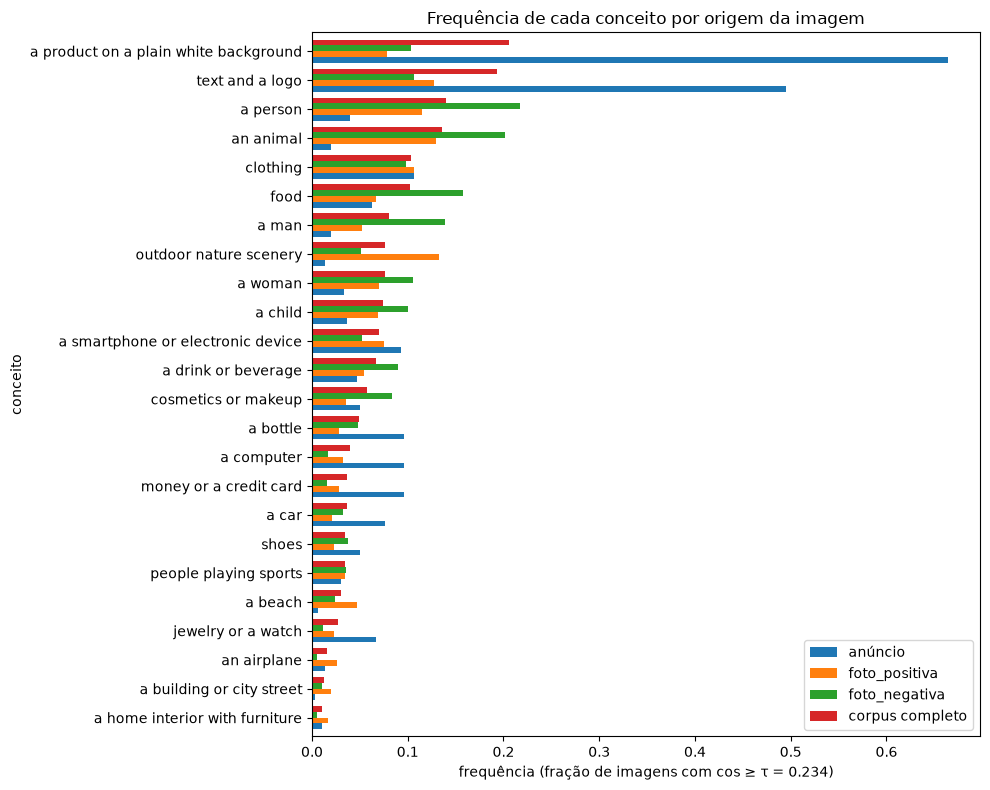

,anúncio,foto_positiva,foto_negativa,corpus completo
conceito,,,,
a product on a plain white background,0.664,0.079,0.104,0.206
text and a logo,0.495,0.128,0.107,0.193
a person,0.040,0.115,0.217,0.140
an animal,0.020,0.129,0.202,0.136
clothing,0.106,0.106,0.098,0.103
food,0.063,0.067,0.158,0.102
a man,0.020,0.052,0.139,0.080
a woman,0.033,0.070,0.105,0.077
outdoor nature scenery,0.013,0.133,0.051,0.077


In [9]:
origins = ["anúncio", "foto_positiva", "foto_negativa"]
by_origin = pd.DataFrame({o: ranking(S[(corpus.origem == o).values], TAU).set_index("conceito")["frequência"] for o in origins})
by_origin["corpus completo"] = rank_all.set_index("conceito")["frequência"]
by_origin = by_origin.sort_values("corpus completo", ascending=True)
by_origin.plot.barh(figsize=(10, 8), width=0.8)
plt.xlabel(f"frequência (fração de imagens com cos ≥ τ = {TAU:.3f})"); plt.title("Frequência de cada conceito por origem da imagem")
plt.tight_layout(); savefig("04_ranking_por_origem"); plt.show()
by_origin.sort_values("corpus completo", ascending=False).round(3)

### 3.4 Sensibilidade ao threshold

O ranking muda se o τ mudar? Comparamos o top-10 com τ = 0,22 (prioriza recall), 0,25, P95 calibrado e 0,28 (prioriza precisão — faixas da Aula 08).

In [10]:
taus = {"0.22 (recall)": 0.22, "0.25": 0.25, f"P95 = {TAU:.3f}": TAU, "0.28 (precisão)": 0.28}
sens = pd.DataFrame({k: ranking(S, v).conceito.head(10).values for k, v in taus.items()}, index=range(1, 11))
sens

,0.22 (recall),0.25,P95 = 0.234,0.28 (precisão)
1,text and a logo,a product on a plain white background,a product on a plain white background,a child
2,a person,an animal,text and a logo,a product on a plain white background
3,a product on a plain white background,text and a logo,a person,jewelry or a watch
4,clothing,food,an animal,an animal
5,an animal,outdoor nature scenery,clothing,a drink or beverage
6,a smartphone or electronic device,a child,food,outdoor nature scenery
7,a man,a person,a man,a beach
8,a woman,clothing,a woman,a smartphone or electronic device
9,food,a woman,outdoor nature scenery,cosmetics or makeup
10,a drink or beverage,cosmetics or makeup,a child,shoes


In [11]:
from scipy.stats import spearmanr
ref = ranking(S, TAU).set_index("conceito").frequência
print("correlação de Spearman entre o ranking com τ calibrado e os demais:")
for k, v in taus.items():
    print(f"  {k:>16}: ρ = {spearmanr(ref, ranking(S, v).set_index('conceito').frequência.reindex(ref.index)).correlation:.3f}")

correlação de Spearman entre o ranking com τ calibrado e os demais:
     0.22 (recall): ρ = 0.964
              0.25: ρ = 0.885
       P95 = 0.234: ρ = 1.000
   0.28 (precisão): ρ = 0.292


### 3.5 Os 5 conceitos mais frequentes — exemplos do corpus

Para cada um dos 5 conceitos do topo, as imagens com maior similaridade (as mais "típicas") e imagens sorteadas aleatoriamente entre as que passam do τ (para ver a qualidade média, não só os melhores casos).

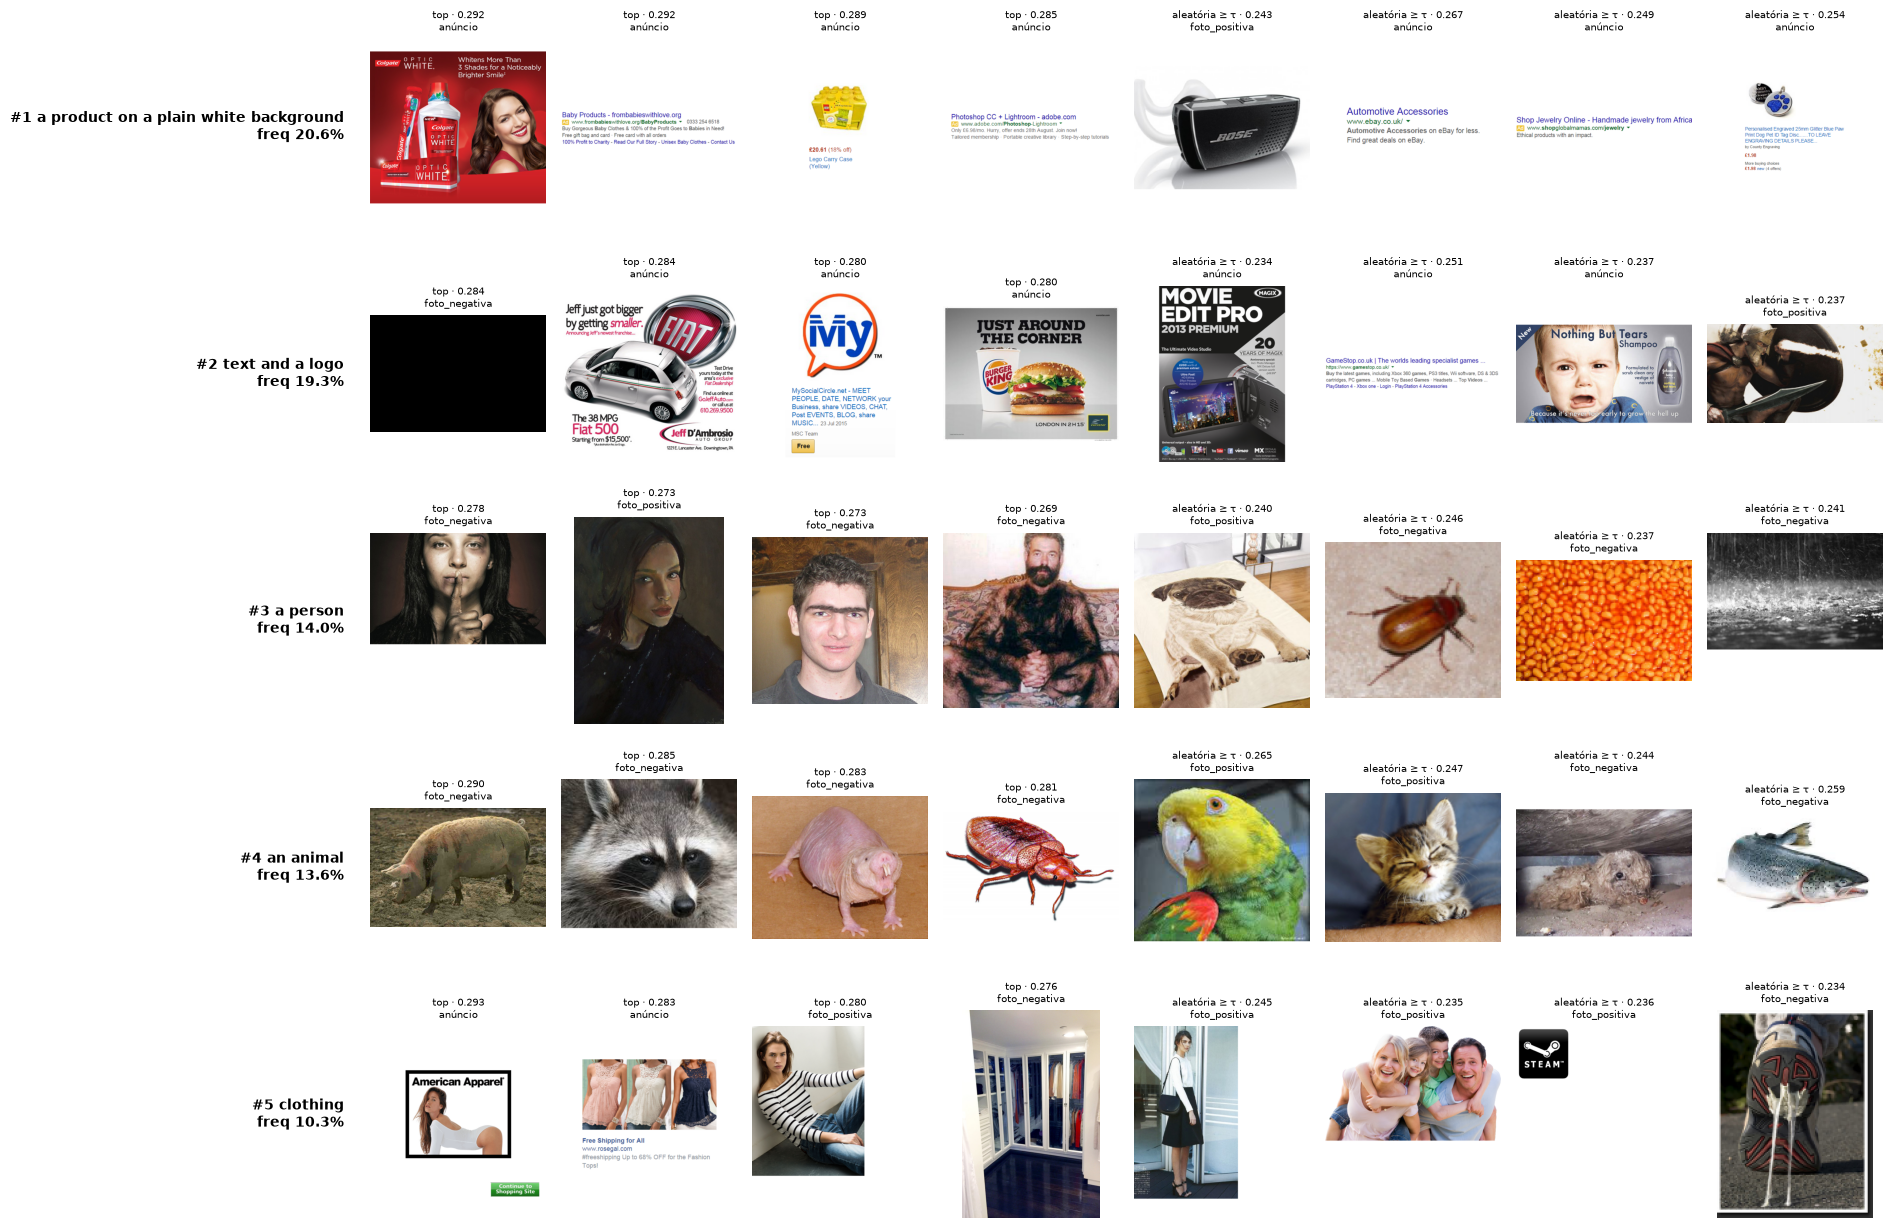

In [12]:
top5 = rank_all.conceito.head(5).tolist()
fig, axes = plt.subplots(5, 8, figsize=(19, 12.5))
rng = np.random.default_rng(SEED)
for i, c in enumerate(top5):
    j = CONCEPTS.index(c); order = np.argsort(-S[:, j])
    above = np.where(S[:, j] >= TAU)[0]
    picks = list(order[:4]) + list(rng.choice(above, size=min(4, len(above)), replace=False))
    for k, idx in enumerate(picks):
        ax = axes[i, k]; ax.imshow(load_rgb(corpus.path[idx])); ax.axis("off")
        tag = "top" if k < 4 else "aleatória ≥ τ"
        ax.set_title(f"{tag} · {S[idx, j]:.3f}\n{corpus.origem[idx]}", fontsize=7)
    axes[i, 0].text(-0.15, 0.5, f"#{i+1} {c}\nfreq {rank_all.frequência[i+1]:.1%}", transform=axes[i, 0].transAxes,
                    ha="right", va="center", fontsize=10, fontweight="bold")
plt.tight_layout(); savefig("05_top5_conceitos_exemplos"); plt.show()

### 3.6 Conceitos × categorias de anúncio

Similaridade média de cada conceito nos anúncios de cada categoria (z-score por conceito, para comparar conceitos com escalas de cosseno diferentes). Mostra se o CLIP associa os conceitos às categorias esperadas — e onde não associa.

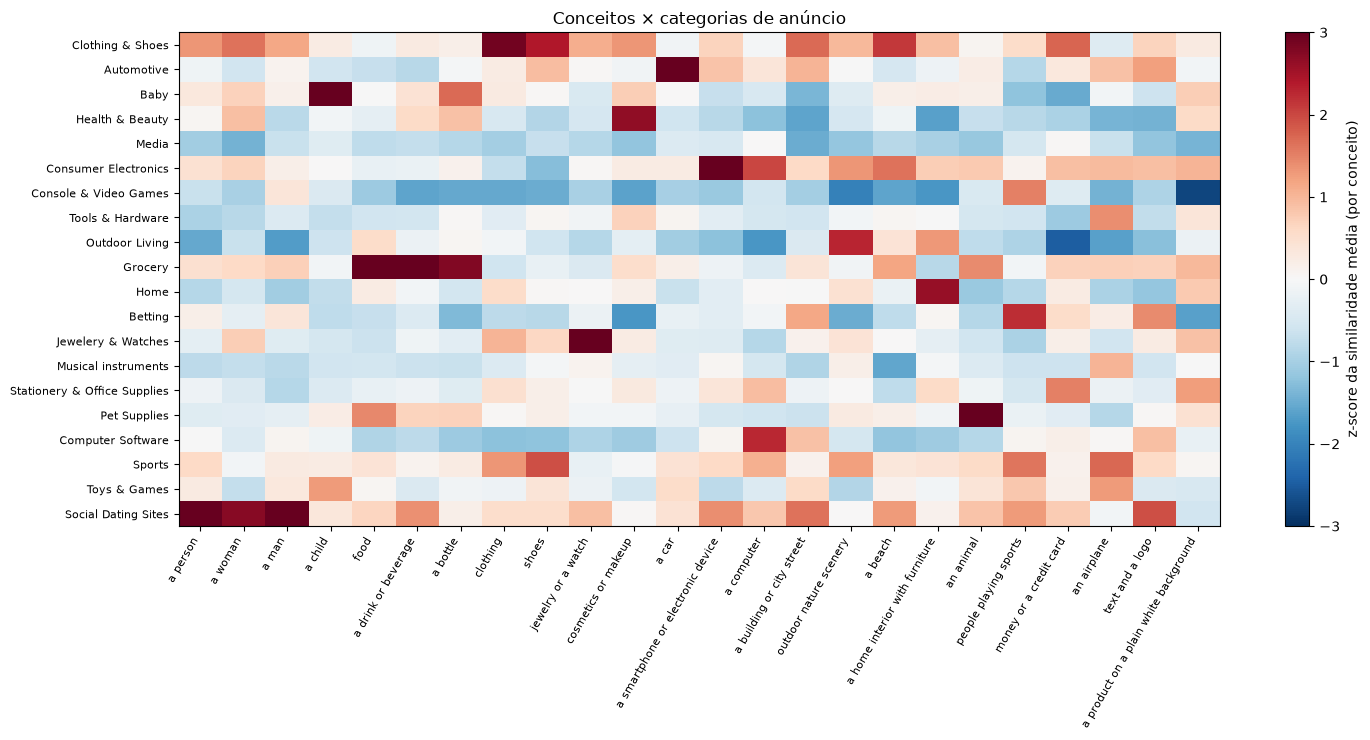

In [13]:
ads_df = corpus[ads_mask].reset_index(drop=True)
M = pd.DataFrame(S[ads_mask], columns=CONCEPTS).groupby(ads_df.categoria.values).mean().loc[cat_names]
Z = (M - M.mean()) / M.std()
plt.figure(figsize=(15, 7.5)); plt.imshow(Z.values, cmap="RdBu_r", vmin=-3, vmax=3, aspect="auto")
plt.yticks(range(20), Z.index, fontsize=8); plt.xticks(range(len(CONCEPTS)), CONCEPTS, rotation=60, ha="right", fontsize=8)
plt.colorbar(label="z-score da similaridade média (por conceito)"); plt.title("Conceitos × categorias de anúncio")
plt.tight_layout(); savefig("06_heatmap_conceito_categoria"); plt.show()

## 4. Item 2.2 — Busca semântica por consulta textual

A consulta é codificada pelo encoder de texto (com o template neutro "a photo of {}"), normalizada e comparada com todos os embeddings de imagem; `torch.topk` devolve as 5 mais similares (Aula 06). As 10 consultas variam em **especificidade** (genérico → específico) e em **abstração** (concreto → abstrato):

| # | consulta | eixo |
|---|---|---|
| 1 | a car | concreto, genérico |
| 2 | a red sports car on the road | concreto, específico (cor + tipo + contexto) |
| 3 | food | concreto, genérico |
| 4 | a cup of coffee | concreto, específico |
| 5 | a smiling woman | concreto, atributo (expressão) |
| 6 | a woman applying makeup | concreto, ação específica |
| 7 | a mobile phone advertisement | concreto, gênero (anúncio) + produto |
| 8 | luxury | abstrato |
| 9 | freedom and adventure | abstrato |
| 10 | family happiness | abstrato, social/afetivo |

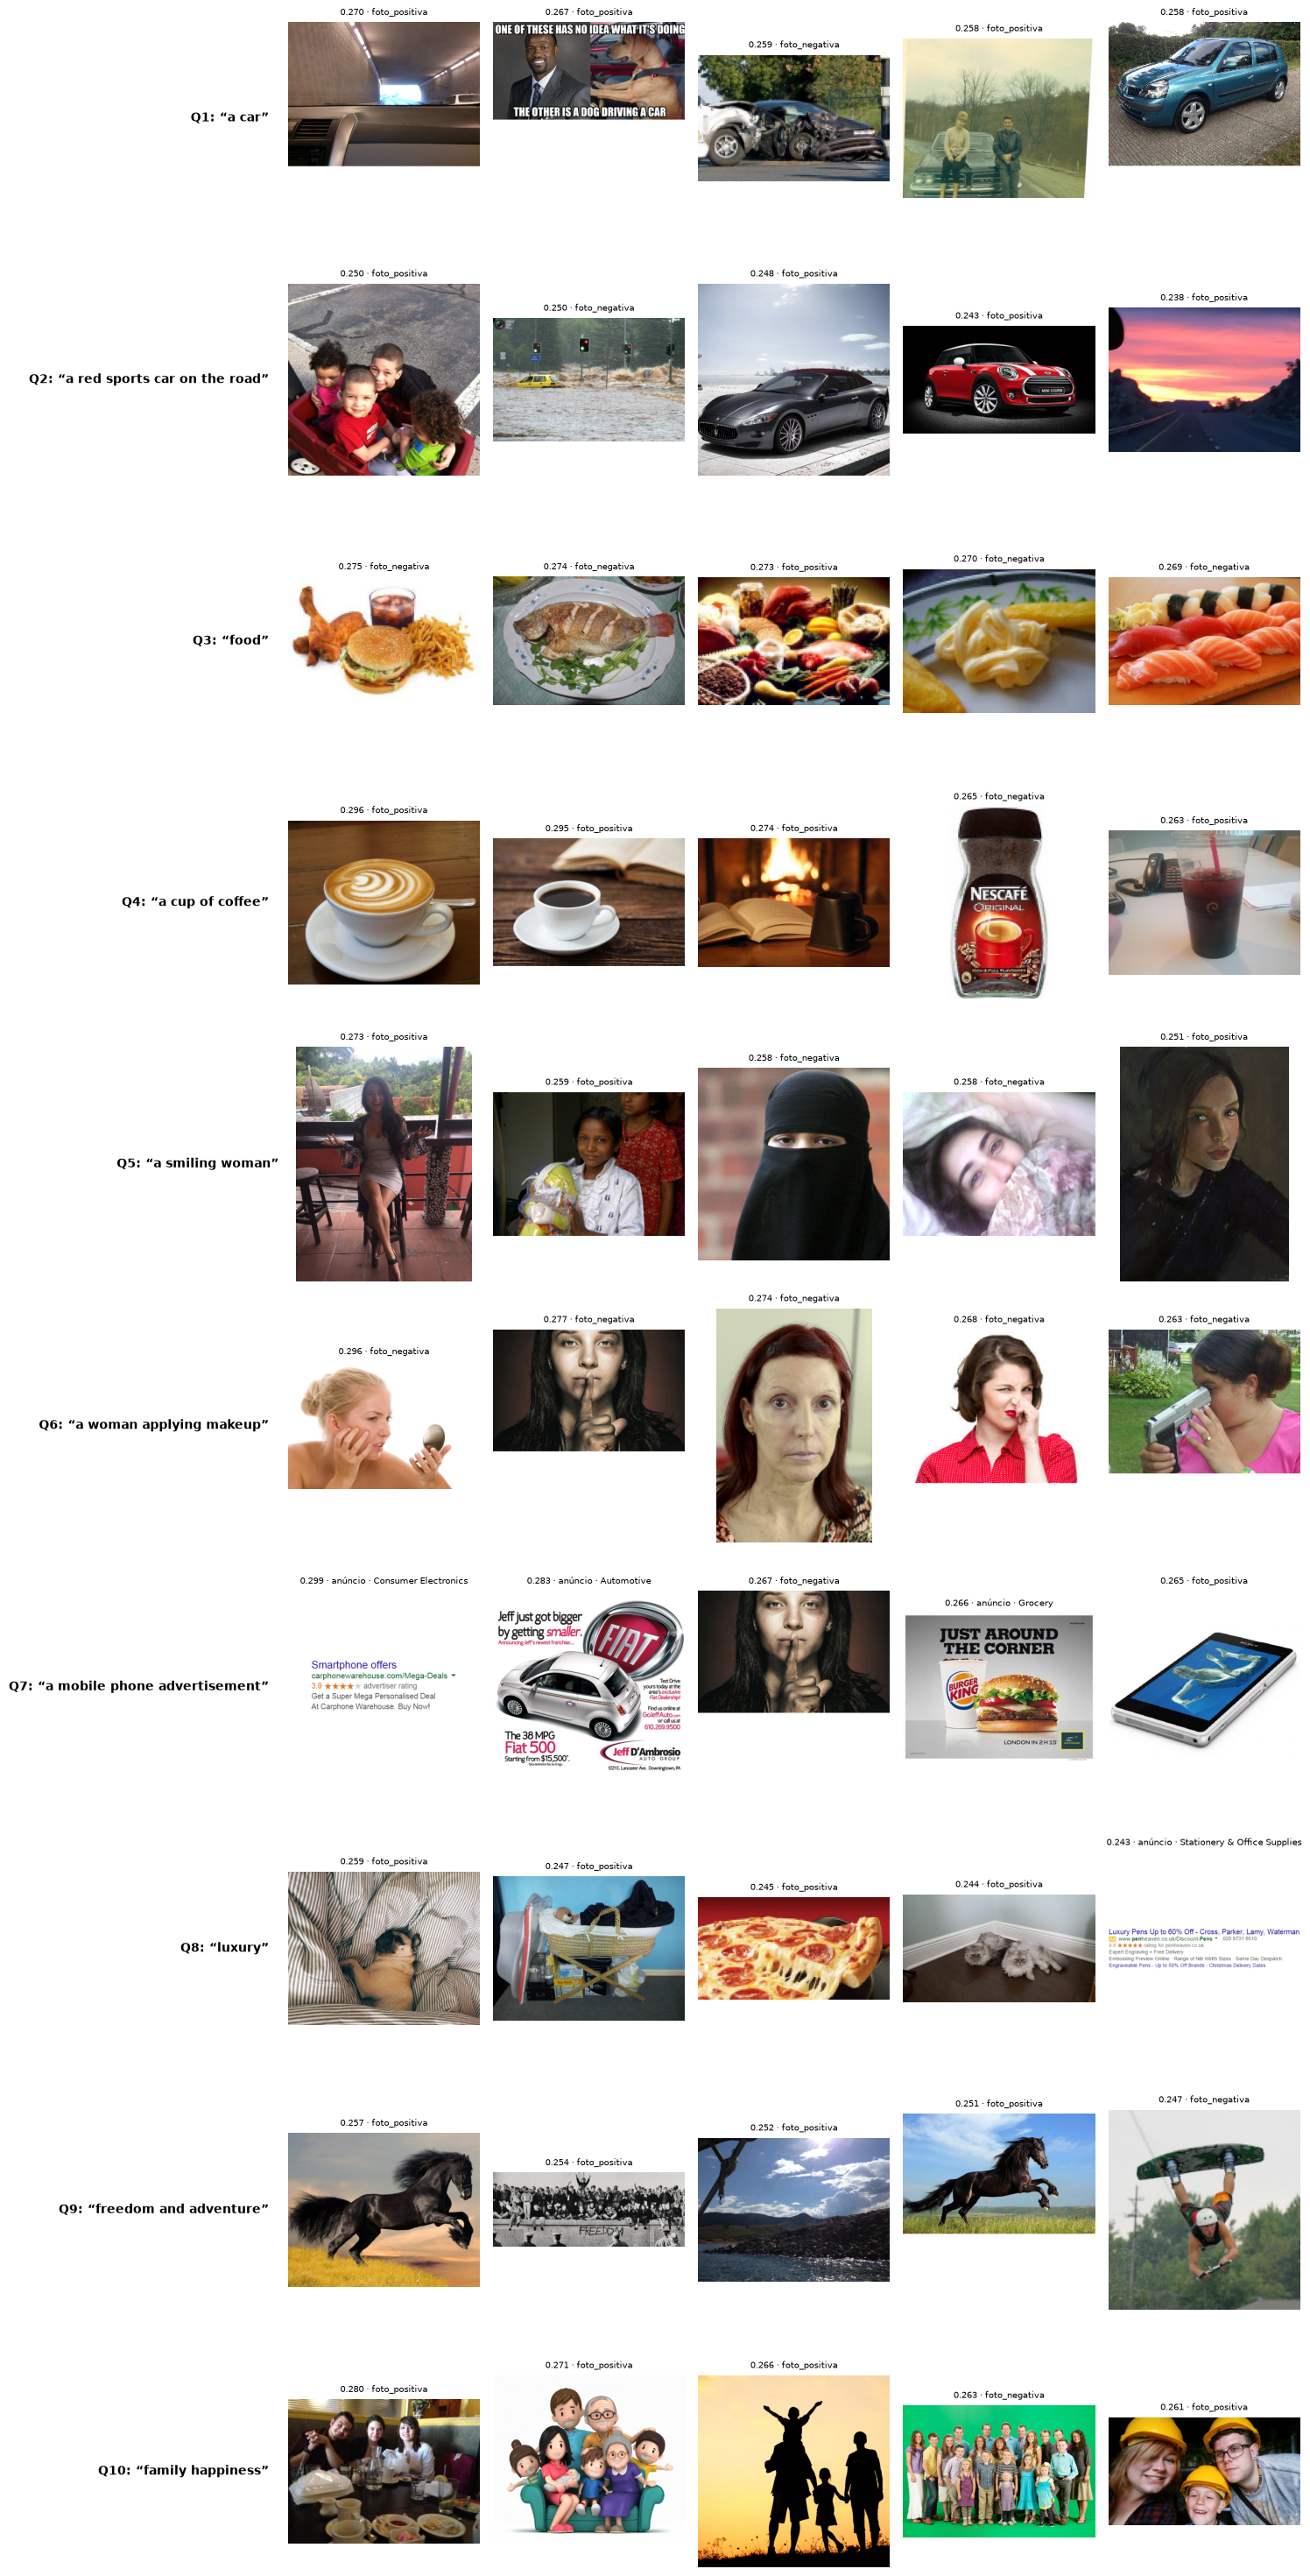

In [14]:
QUERIES = ["a car", "a red sports car on the road", "food", "a cup of coffee", "a smiling woman", "a woman applying makeup",
           "a mobile phone advertisement", "luxury", "freedom and adventure", "family happiness"]
Q_TXT = encode_concepts(QUERIES, ["a photo of {}."])
SQ = IMG @ Q_TXT.T                                                   # [N, 10]
scores, indices = torch.topk(SQ, k=5, dim=0)                          # top-5 por consulta

fig, axes = plt.subplots(len(QUERIES), 5, figsize=(15, 3.0 * len(QUERIES)))
for q, query in enumerate(QUERIES):
    for k in range(5):
        idx = int(indices[k, q]); ax = axes[q, k]; ax.imshow(load_rgb(corpus.path[idx])); ax.axis("off")
        cat = f" · {corpus.categoria[idx]}" if corpus.origem[idx] == "anúncio" else ""
        ax.set_title(f"{scores[k, q]:.3f} · {corpus.origem[idx]}{cat}", fontsize=7)
    axes[q, 0].text(-0.1, 0.5, f"Q{q+1}: “{query}”", transform=axes[q, 0].transAxes, ha="right", va="center", fontsize=10, fontweight="bold")
plt.tight_layout(); savefig("07_busca_top5"); plt.show()

### 4.1 Variando o threshold por consulta

Quantas imagens do corpus cada consulta "aceita" em cada threshold, e qual o score da 5ª imagem (se a 5ª fica abaixo do τ, o top-5 já está trazendo imagens que o modelo não considera alinhadas). Requisito da Aula 08: variar o threshold e documentar as imagens recuperadas.

In [15]:
tab = pd.DataFrame({"consulta": QUERIES, "score top-1": scores[0].numpy(), "score top-5": scores[4].numpy()})
for name, v in taus.items():
    tab[f"n ≥ {name}"] = (SQ >= v).sum(0).numpy()
tab["% anúncios no top-5"] = [(corpus.origem[indices[:, q].numpy()] == "anúncio").mean() for q in range(len(QUERIES))]
tab.round(3)

,consulta,score top-1,score top-5,n ≥ 0.22 (recall),n ≥ 0.25,n ≥ P95 = 0.234,n ≥ 0.28 (precisão),% anúncios no top-5
0,a car,0.270,0.258,58,9,27,0,0.0
1,a red sports car on the road,0.250,0.238,11,2,6,0,0.0
2,food,0.275,0.269,195,63,112,0,0.0
3,a cup of coffee,0.296,0.263,22,10,13,2,0.0
4,a smiling woman,0.273,0.251,73,5,22,0,0.0
5,a woman applying makeup,0.296,0.263,74,10,36,1,0.0
6,a mobile phone advertisement,0.299,0.265,292,26,117,2,0.6
7,luxury,0.259,0.243,144,1,28,0,0.2
8,freedom and adventure,0.257,0.247,74,4,21,0,0.0
9,family happiness,0.280,0.261,56,10,27,1,0.0


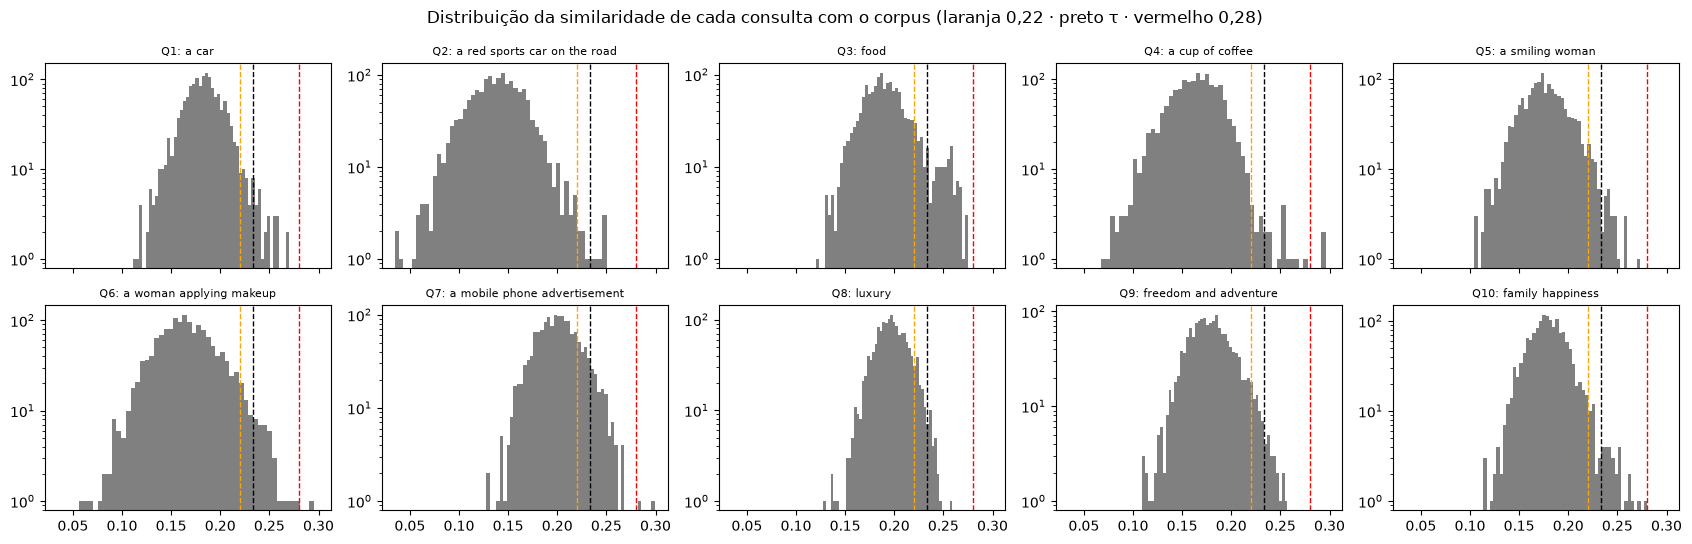

In [16]:
fig, axes = plt.subplots(2, 5, figsize=(17, 5.5), sharex=True)
for q, ax in enumerate(axes.ravel()):
    ax.hist(SQ[:, q].numpy(), bins=50, color="gray")
    for v, c in [(0.22, "orange"), (TAU, "k"), (0.28, "red")]: ax.axvline(v, color=c, ls="--", lw=1)
    ax.set_title(f"Q{q+1}: {QUERIES[q][:28]}", fontsize=8); ax.set_yscale("log")
fig.suptitle("Distribuição da similaridade de cada consulta com o corpus (laranja 0,22 · preto τ · vermelho 0,28)")
plt.tight_layout(); savefig("08_distribuicao_scores_consultas"); plt.show()

### 4.2 O que entra entre τ = 0,28 e τ = 0,22? (consultas selecionadas)

Para três consultas, mostramos imagens que só são aceitas quando o threshold cai de 0,28 para 0,22 — a "zona cinzenta" onde o alinhamento é fraco.

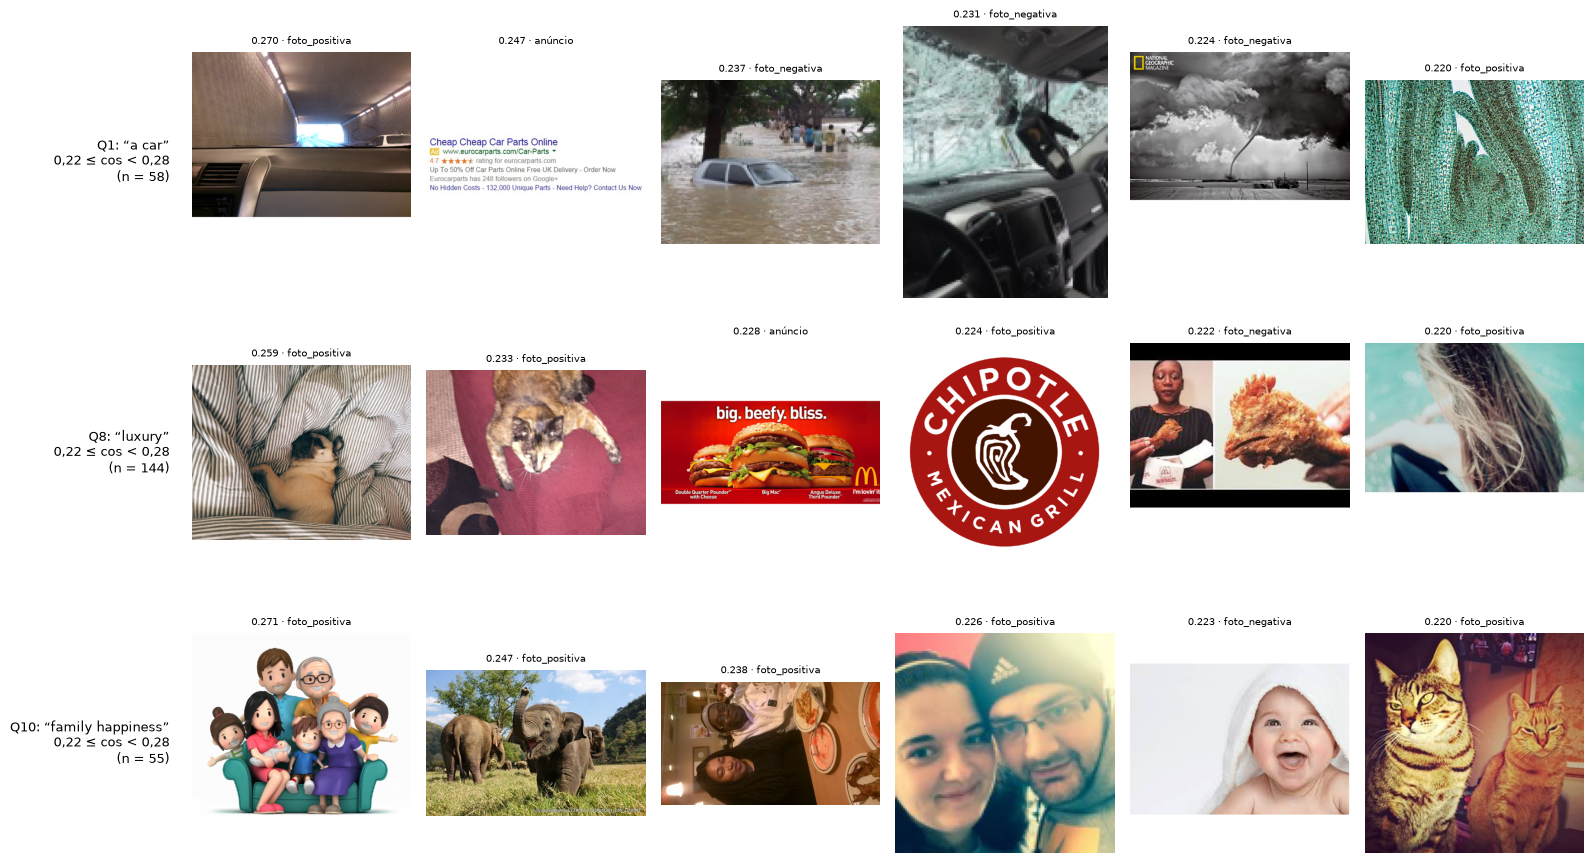

In [17]:
sel_q = [0, 7, 9]
fig, axes = plt.subplots(len(sel_q), 6, figsize=(16, 3.0 * len(sel_q)))
for r, q in enumerate(sel_q):
    s = SQ[:, q].numpy(); band = np.where((s >= 0.22) & (s < 0.28))[0]
    pick = band[np.argsort(-s[band])][np.linspace(0, len(band) - 1, 6).astype(int)] if len(band) >= 6 else band
    for k in range(6):
        ax = axes[r, k]; ax.axis("off")
        if k < len(pick):
            ax.imshow(load_rgb(corpus.path[pick[k]])); ax.set_title(f"{s[pick[k]]:.3f} · {corpus.origem[pick[k]]}", fontsize=7)
    axes[r, 0].text(-0.1, 0.5, f"Q{q+1}: “{QUERIES[q]}”\n0,22 ≤ cos < 0,28\n(n = {len(band)})", transform=axes[r, 0].transAxes, ha="right", va="center", fontsize=9)
plt.tight_layout(); savefig("09_zona_cinzenta_threshold"); plt.show()

## 5. Por que o CLIP recupera imagens por texto sem nenhum treino supervisionado

**Duas torres, um espaço.** O CLIP tem um encoder de imagem (aqui um ViT-B/32) e um encoder de texto (Transformer). Os dois projetam a entrada para o **mesmo espaço de 512 dimensões**, normalizado em L2 (a hiperesfera da Aula 06). Na busca, consulta e imagens nunca se comparam por rótulos: comparam-se **vetores no mesmo espaço**, por cosseno.

**O pré-treino contrastivo é o que alinha as duas torres.** Em cada *batch* de N pares (imagem, legenda) da web (400 M pares, WIT), o CLIP calcula a matriz N×N de similaridades e minimiza a **InfoNCE simétrica**:

`L = ½ [ CE(linhas: imagem → texto certo) + CE(colunas: texto → imagem certa) ]`, com logits `S_ij = cos(I_i, T_j) / τ`.

Isso **maximiza a similaridade dos N pares corretos (diagonal)** e **minimiza a dos N²−N pares errados**. Na prática, o modelo aprende uma informação mútua alta entre o que a imagem mostra e o que a legenda diz.

Duas consequências explicam a busca sem treino:
1. **O texto vira o "classificador".** Qualquer frase gera um vetor de consulta, então o vocabulário é **aberto**. Não existe a camada `Linear(D, 1000)` de um modelo supervisionado, que só conhece as classes vistas no treino (Aula 06). Classificação zero-shot e busca são a mesma operação: `argmax / top-k` de `I · Tᵀ`.
2. **A supervisão veio "de graça" da linguagem natural.** As legendas descrevem objetos, cenas, ações, estilos e até texto escrito, uma supervisão muito mais rica do que um rótulo único. Por isso conceitos como "liberdade" ou "family happiness" têm um vetor útil, mesmo que nunca tenham sido uma "classe".

**Evidência neste corpus.** Usamos os ~1.200 pares foto × legenda escrita pelo participante (nada é ajustado neles):
- **busca legenda → foto**: para cada legenda, em que posição do ranking (entre as 1.183 fotos legendadas) aparece a foto certa (*Recall@K*);
- **lacuna entre modalidades** (*modality gap*): mesmo alinhados, imagens e textos ocupam regiões diferentes da hiperesfera. Isso explica os cossenos absolutos baixos (~0,2–0,3) e a necessidade de calibrar τ (seção 3.2).

busca legenda → foto entre 1183 fotos | CLIP: R@1 = 39.9%, R@5 = 64.3%, R@10 = 72.8%, R@50 = 86.1%
acaso (ranking aleatório):            R@1 = 0.08%, R@5 = 0.42%, R@10 = 0.85%, R@50 = 4.23%
posição mediana da foto certa: 2 de 1183
cos médio — imagem×imagem 0.459 | texto×texto 0.745 | imagem×texto correto 0.281 | imagem×texto errado 0.190 | distância entre os centroides das modalidades 0.907


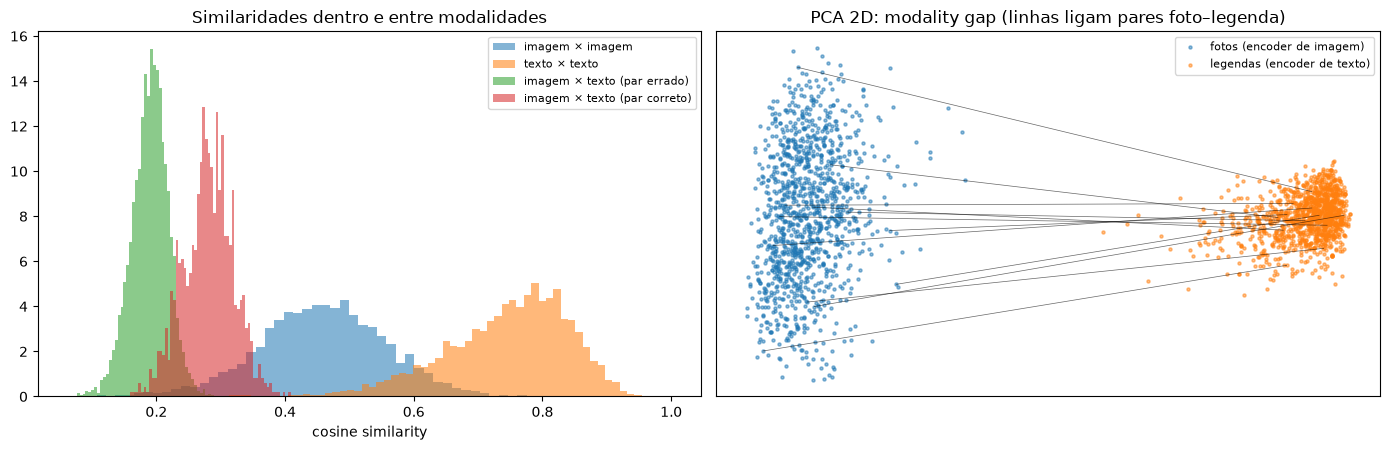

In [18]:
I_tag, T_tag = IMG[tagged], L_TXT                                       # pares alinhados: foto i ↔ legenda i
S_it = (T_tag @ I_tag.T).numpy()                                         # [legendas, fotos]
rank = (S_it > np.diag(S_it)[:, None]).sum(1)                            # nº de fotos com score maior que a foto certa
n_t = len(rank)
rec = {f"R@{k}": float((rank < k).mean()) for k in [1, 5, 10, 50]}
rec_rand = {f"R@{k}": k / n_t for k in [1, 5, 10, 50]}
print(f"busca legenda → foto entre {n_t} fotos | CLIP: " + ", ".join(f"{k} = {v:.1%}" for k, v in rec.items()))
print("acaso (ranking aleatório):            " + ", ".join(f"{k} = {v:.2%}" for k, v in rec_rand.items()))
print(f"posição mediana da foto certa: {int(np.median(rank)) + 1} de {n_t}")

rng_ = np.random.default_rng(0); ii = rng_.integers(0, n_t, 5000); jj = rng_.integers(0, n_t, 5000); ok_ = ii != jj
cos_ii = (I_tag[ii[ok_]] * I_tag[jj[ok_]]).sum(1).numpy()              # imagem × imagem (aleatórias)
cos_tt = (T_tag[ii[ok_]] * T_tag[jj[ok_]]).sum(1).numpy()              # texto × texto (aleatórios)
cos_pos = np.diag(S_it); cos_neg = S_it[ii[ok_], jj[ok_]]
gap = (I_tag.mean(0) - T_tag.mean(0)).norm().item()
print(f"cos médio — imagem×imagem {cos_ii.mean():.3f} | texto×texto {cos_tt.mean():.3f} | imagem×texto correto {cos_pos.mean():.3f} | "
      f"imagem×texto errado {cos_neg.mean():.3f} | distância entre os centroides das modalidades {gap:.3f}")

from sklearn.decomposition import PCA
Z2 = PCA(2, random_state=0).fit_transform(torch.cat([I_tag, T_tag]).numpy())
fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))
ax[0].hist(cos_ii, bins=60, alpha=.55, density=True, label="imagem × imagem")
ax[0].hist(cos_tt, bins=60, alpha=.55, density=True, label="texto × texto")
ax[0].hist(cos_neg, bins=60, alpha=.55, density=True, label="imagem × texto (par errado)")
ax[0].hist(cos_pos, bins=60, alpha=.55, density=True, label="imagem × texto (par correto)")
ax[0].set_xlabel("cosine similarity"); ax[0].set_title("Similaridades dentro e entre modalidades"); ax[0].legend(fontsize=8)
ax[1].scatter(Z2[:n_t, 0], Z2[:n_t, 1], s=5, alpha=.5, label="fotos (encoder de imagem)")
ax[1].scatter(Z2[n_t:, 0], Z2[n_t:, 1], s=5, alpha=.5, label="legendas (encoder de texto)")
for k in rng_.choice(n_t, 12, replace=False):
    ax[1].plot([Z2[k, 0], Z2[n_t + k, 0]], [Z2[k, 1], Z2[n_t + k, 1]], "k-", lw=.5, alpha=.6)
ax[1].set_title("PCA 2D: modality gap (linhas ligam pares foto–legenda)"); ax[1].legend(fontsize=8); ax[1].set_xticks([]); ax[1].set_yticks([])
plt.tight_layout(); savefig("10_alinhamento_modalidades"); plt.show()

## 6. Consulta textual: CLIP × BERT (tokenização, padding e attention mask)

A consulta "a red sports car on the road" passa por um caminho parecido com o do BERT (Aula 03), mas com diferenças importantes no tratamento do **padding** e na **máscara de atenção**:

| | CLIP (encoder de texto) | BERT |
|---|---|---|
| Tokenização | BPE em bytes, vocabulário de 49.408 (Aula 02) | WordPiece, vocabulário de 30.522 |
| Tokens especiais | `<start_of_text>` … `<end_of_text>` | `[CLS]` … `[SEP]` |
| Comprimento | **fixo em 77**, sempre preenchido com o id 0 | variável: *padding* até o maior do *batch* ou `max_length`, com `[PAD]` |
| Máscara de atenção | **causal** (triangular, fixa): cada token só vê os anteriores | **bidirecional** + `attention_mask` (1 = token real, 0 = padding) |
| Representação da frase | estado do token **`<end_of_text>`**, projetado para 512-d | estado do **`[CLS]`** (ou *pooling*) |

**Por que o BERT precisa de `attention_mask` e o CLIP não usa uma.** No BERT, a atenção é bidirecional: sem máscara, os tokens reais (inclusive o [CLS]) atenderiam aos `[PAD]` e a representação mudaria conforme o tamanho do *padding* do *batch*. A `attention_mask` soma −∞ aos *scores* das colunas de padding antes do softmax, o mesmo mecanismo do teste 4 do notebook A1, e zera o peso delas. No CLIP, a máscara **causal** já garante que o token `<end_of_text>` só "vê" a si mesmo e os tokens **anteriores**. Os zeros de padding vêm **depois** dele, então nunca entram no cálculo do vetor da frase. O teste abaixo comprova isso trocando o conteúdo do padding.

In [19]:
queries_demo = ["a car", "a red sports car on the road"]
tok = clip.tokenize(queries_demo)                                          # [2, 77]
eot_pos = tok.argmax(dim=-1)                                               # <end_of_text> tem o maior id (49407)
for q_, t_, e_ in zip(queries_demo, tok, eot_pos):
    print(f"CLIP | {q_!r}: ids = {t_[:e_ + 3].tolist()} …  (comprimento fixo {t_.numel()}, <eot> na posição {e_.item()}, "
          f"{int((t_ == 0).sum())} posições de padding)")
mask = model.build_attention_mask() if hasattr(model, "build_attention_mask") else model.transformer.resblocks[0].attn_mask
print("máscara causal do encoder de texto do CLIP (canto 5×5):\n", mask[:5, :5])

with torch.no_grad():
    t_dev = tok.to(DEVICE)
    e_ref = model.encode_text(t_dev).float()
    t_mod = t_dev.clone()
    for r_, e_ in enumerate(eot_pos):                                    # troca o conteúdo do padding (após o <eot>)
        t_mod[r_, e_ + 1:] = 1000 + r_
    e_mod = model.encode_text(t_mod).float()
print(f"diferença máxima no embedding da frase após trocar o padding: {(e_ref - e_mod).abs().max().item():.2e}  "
      f"→ a máscara causal + pooling no <eot> tornam o padding irrelevante")

try:
    from transformers import BertTokenizerFast
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "transformers"], check=True)
    from transformers import BertTokenizerFast
bert_tok = BertTokenizerFast.from_pretrained("bert-base-uncased")
enc = bert_tok(queries_demo, padding="max_length", max_length=12, truncation=True, return_tensors="pt")
for i_, q_ in enumerate(queries_demo):
    print(f"\nBERT | {q_!r}")
    print("  tokens        :", bert_tok.convert_ids_to_tokens(enc["input_ids"][i_]))
    print("  input_ids     :", enc["input_ids"][i_].tolist())
    print("  attention_mask:", enc["attention_mask"][i_].tolist(), " ← 0 = [PAD]: recebe −∞ nos scores e peso 0 no softmax")

CLIP | 'a car': ids = [49406, 320, 1615, 49407, 0, 0] …  (comprimento fixo 77, <eot> na posição 3, 73 posições de padding)
CLIP | 'a red sports car on the road': ids = [49406, 320, 736, 2054, 1615, 525, 518, 1759, 49407, 0, 0] …  (comprimento fixo 77, <eot> na posição 8, 68 posições de padding)
máscara causal do encoder de texto do CLIP (canto 5×5):
 tensor([[0., -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf],
        [0., 0., 0., 0., -inf],
        [0., 0., 0., 0., 0.]])
diferença máxima no embedding da frase após trocar o padding: 0.00e+00  → a máscara causal + pooling no <eot> tornam o padding irrelevante


.\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


.\.venv\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in ~\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)



BERT | 'a car'
  tokens        : ['[CLS]', 'a', 'car', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
  input_ids     : [101, 1037, 2482, 102, 0, 0, 0, 0, 0, 0, 0, 0]
  attention_mask: [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]  ← 0 = [PAD]: recebe −∞ nos scores e peso 0 no softmax

BERT | 'a red sports car on the road'
  tokens        : ['[CLS]', 'a', 'red', 'sports', 'car', 'on', 'the', 'road', '[SEP]', '[PAD]', '[PAD]', '[PAD]']
  input_ids     : [101, 1037, 2417, 2998, 2482, 2006, 1996, 2346, 102, 0, 0, 0]
  attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0]  ← 0 = [PAD]: recebe −∞ nos scores e peso 0 no softmax


## 7. Resultados consolidados

In [20]:
summary = dict(n_imagens=len(corpus), por_origem=corpus.origem.value_counts().to_dict(), tau_p95=TAU, tau_categoria_descartado=TAU_CAT,
               zero_shot_top1=float(top1), zero_shot_top3=float(top3),
               top10=rank_all.head(10)[["conceito", "frequência", "score_médio_presentes"]].round(4).to_dict("records"),
               consultas=tab.round(4).to_dict("records"), busca_legenda_foto=rec, modality_gap=gap)
(FIG_DIR / "results.json").write_text(json.dumps(summary, indent=2, ensure_ascii=False, default=float), encoding="utf-8")
print(json.dumps(summary, indent=2, ensure_ascii=False, default=float))

{
  "n_imagens": 1501,
  "por_origem": {
    "foto_positiva": 611,
    "foto_negativa": 589,
    "anúncio": 301
  },
  "tau_p95": 0.23368288576602936,
  "tau_categoria_descartado": 0.274478554725647,
  "zero_shot_top1": 0.5980066445182725,
  "zero_shot_top3": 0.7674418604651163,
  "top10": [
    {
      "conceito": "a product on a plain white background",
      "frequência": 0.2059,
      "score_médio_presentes": 0.25360000133514404
    },
    {
      "conceito": "text and a logo",
      "frequência": 0.1932,
      "score_médio_presentes": 0.24719999730587006
    },
    {
      "conceito": "a person",
      "frequência": 0.1399,
      "score_médio_presentes": 0.24390000104904175
    },
    {
      "conceito": "an animal",
      "frequência": 0.1359,
      "score_médio_presentes": 0.25209999084472656
    },
    {
      "conceito": "clothing",
      "frequência": 0.1033,
      "score_médio_presentes": 0.24529999494552612
    },
    {
      "conceito": "food",
      "frequência": 0.1019,


## 8. Análise

### 6.1 O espaço de embeddings "entende" este corpus?

Sim, dentro de limites. A classificação **zero-shot** das 300 propagandas em 20 categorias acerta **59,8% no top-1** e **76,7% no top-3**, contra 5% de acerto ao acaso, sem nenhum treino. As categorias com nomes visualmente concretos (Pet Supplies, Automotive, Jewelery & Watches, Baby) vão melhor. As que dependem de contexto ou texto (Media, Betting, Computer Software) vão pior. O heatmap conceito × categoria confirma que as associações fazem sentido:

- Automotive ↔ *a car*
- Pet Supplies ↔ *an animal*
- Jewelery & Watches ↔ *jewelry or a watch*
- Health & Beauty ↔ *cosmetics or makeup*
- Grocery ↔ *food / drink / bottle*
- Baby ↔ *a child*
- Social Dating Sites ↔ *a person / a woman / a man*
- Outdoor Living ↔ *outdoor nature scenery*

As categorias sem conceito correspondente no vocabulário (Media, Console & Video Games, Musical instruments) ficam frias em todas as colunas, o que também é coerente.

### 6.2 Threshold

O τ adotado (**0,234**) é o percentil 95 de **1,4 milhão de pares negativos aleatórios** (foto × legenda de outra foto). Ele deixa passar **87%** dos pares verdadeiros (foto × própria legenda, mediana 0,281), contra 5% dos falsos. Fica entre as faixas "alinhamento fraco" e "forte" da Aula 08, e é coerente com a faixa de ruído de fundo da aula: mediana dos negativos 0,191.

A tentativa descartada (anúncio × categoria errada) mostrou na prática por que **calibrar com pares que não representam a tarefa** é perigoso. O componente comum "isto é um anúncio" elevou os negativos (mediana 0,238) e gerou τ = 0,274, com o qual quase nenhum conceito passava em nenhuma imagem.

O ranking é **estável em torno do τ escolhido**: correlação de Spearman ρ = 0,96 com τ = 0,22 e ρ = 0,89 com τ = 0,25. Ele **desmorona com τ = 0,28** (ρ = 0,29), porque pouquíssimas imagens passam e a ordem vira ruído de contagem.

### 6.3 Ranking dos conceitos e o que ele revela

Os 5 conceitos mais frequentes no corpus completo (1.501 imagens) são:

1. *a product on a plain white background*: 20,6%
2. *text and a logo*: 19,3%
3. *a person*: 14,0%
4. *an animal*: 13,6%
5. *clothing*: 10,3%

Separar por origem é o que dá sentido ao ranking:

- **Anúncios** são dominados por *produto em fundo branco* (66%) e *texto e logo* (50%). Em seguida vêm garrafa, computador, dinheiro/cartão, carro e joias, ou seja, **o produto e a marca**. Pessoas aparecem em menos de 5% dos anúncios.
- **Fotos que os participantes gostam** concentram *natureza ao ar livre*, *animal* (animais de estimação), *texto/logo* (memes) e *praia*.
- **Fotos que os participantes rejeitam** concentram *pessoa*, *animal* (insetos, roedores), *comida* e *homem*.

Há aqui uma leitura de negócio: o vocabulário visual dos anúncios (produto isolado + texto) é quase o oposto do vocabulário das imagens que esses consumidores dizem gostar (paisagens, animais, praia). O ADS-16 foi criado justamente para estudar esse descompasso entre anúncio e preferência.

**Qualidade de cada conceito do top-5**, pela inspeção das imagens (4 de maior score e 4 sorteadas acima de τ):

- **an animal: alta precisão.** Porco, guaxinim, rato-toupeira, percevejo, papagaio, gatinho, peixe: todas corretas.
- **text and a logo: boa.** Anúncios da Fiat, Burger King, Movie Edit Pro, xampu. Erro notável: uma **imagem totalmente preta** ficou com score 0,284. Uma imagem sem conteúdo não está "perto" de nenhum texto em particular, mas o cosseno não é probabilidade (Aula 08) e pode ficar alto por acaso.
- **clothing: boa no topo** (anúncio da American Apparel, roupas femininas, closet). Na amostra aleatória entram casos-limite: família, logo da Steam, sola de sapato.
- **a product on a plain white background: captura o *layout*, não o produto.** Acerta anúncios de produto (Colgate, Bose), mas os **anúncios só de texto** (texto azul sobre fundo branco) também passam: para o CLIP, "fundo branco" pesa mais que "produto". O conceito mede "página branca com pouco conteúdo".
- **a person: precisão baixa abaixo do topo.** Os 4 primeiros são retratos corretos, mas as 4 sorteadas acima de τ são um pug, um besouro, feijão cozido e chuva. Conceitos **genéricos** como "a person" têm similaridade-base mais alta com qualquer imagem, e um τ único para todos os conceitos favorece esses genéricos. Melhoria: calibrar τ **por conceito** (P95 dos negativos de cada prompt) ou usar a margem em relação ao 2º conceito mais provável.

### 6.4 Busca semântica: consulta por consulta

Precisão@5 por inspeção visual (imagem relevante = contém o que a consulta descreve):

| # | Consulta | Tipo | P@5 | O que aconteceu |
|---|---|---|---|---|
| 1 | a car | concreto, genérico | 5/5 | Interior de carro num túnel, carro batido, pessoas sentadas num carro, hatch azul e um **meme** cuja legenda diz "...A DOG DRIVING A CAR": o CLIP **leu o texto da imagem** (*typographic bias*). |
| 2 | a red sports car on the road | concreto, específico | 1/5 | **Falha de composição.** Recupera um esportivo **cinza** (Maserati), um Mini **vermelho** em estúdio, crianças num carrinho **vermelho**, uma estrada ao pôr do sol **avermelhado** e uma rua alagada. Cada atributo ("vermelho", "esportivo", "estrada") é satisfeito por uma imagem diferente: o CLIP trata a frase como um "saco de conceitos" e não liga o atributo ao objeto (*attribute binding*). |
| 3 | food | concreto, genérico | 5/5 | Hambúrguer com fritas, peixe, legumes, massa, sushi. 4 das 5 vêm das **fotos rejeitadas**: os participantes associam comida a nojo, e o CLIP recupera o conteúdo independentemente do sentimento. |
| 4 | a cup of coffee | concreto, específico | 4/5 | Café com *latte art*, xícara, caneca com livro e lareira, pote de Nescafé. Erro: copo de suco vermelho com canudo. |
| 5 | a smiling woman | concreto + atributo | 2/5 | Todas são **mulheres**, mas o **sorriso** é ignorado: há mulher de niqab (rosto coberto) e retratos sérios. O atributo de expressão facial pesa pouco frente ao substantivo. |
| 6 | a woman applying makeup | concreto + ação | 1/5 | Só a 1ª (mulher com espelho aplicando creme) está correta. As demais são **closes de rosto feminino** (dedo nos lábios, mão no nariz, mulher com arma de brinquedo). A **ação** se perde e sobra "rosto de mulher em close". |
| 7 | a mobile phone advertisement | gênero + produto | 2/5 | Anúncio de texto "Smartphone offers" (correto, pela leitura do texto) e uma foto de celular Sony (o produto, mas não um anúncio). O resto são **anúncios de outros produtos** (Fiat, Burger King). A consulta é decomposta em "anúncio" **ou** "celular". É a única consulta com 60% de anúncios no top-5. |
| 8 | luxury | abstrato | 1/5 | Scores baixos (top-1 0,259; só 1 imagem ≥ 0,25). O único acerto é um anúncio de texto "**Luxury** Pens up to 60% off": casamento **lexical**, não visual. O resto (pet na cama, pizza, gatos no canto) não tem relação clara. "Luxo" não tem um correlato visual único nesse corpus. |
| 9 | freedom and adventure | abstrato | 4/5 | **Proxies visuais** bem escolhidos: cavalos galopando, paisagem de montanha, *wakeboard* em salto, multidão. É o imaginário publicitário clássico de "liberdade", e o CLIP aprendeu esses clichês no WIT-400M. |
| 10 | family happiness | abstrato, social | 4/5 | Família à mesa, família em desenho no sofá, silhueta de família ao pôr do sol (imagem típica de banco de imagens), foto de família numerosa. A 5ª (amigos com capacete) é parcial. |

**Padrões observados:**
1. **Genérico e concreto funciona; especificidade composicional falha.** "a car" e "food" ficam com 5/5, mas cada atributo acrescentado (cor, expressão, ação) é tratado de forma independente do objeto. É uma limitação conhecida de modelos contrastivos com embedding global.
2. **Abstrato funciona quando existe um clichê visual** ("liberdade" vira cavalo e montanha; "família feliz" vira silhueta ao pôr do sol). Falha quando não existe ("luxo"), e aí o modelo se agarra a **texto escrito na imagem**.
3. **Leitura de texto (*typographic bias*)** aparece em 3 consultas (meme do carro, "Smartphone offers", "Luxury Pens"). Num corpus de publicidade, isso é ao mesmo tempo útil (anúncios de texto são recuperáveis) e perigoso (o texto domina o conteúdo visual).
4. **Viés de template contra anúncios:** com o template "a photo of…", as fotos naturais dos participantes vencem os anúncios (diagramados, com texto) em 9 das 10 consultas. Para buscar **anúncios**, o template deveria ser "an advertisement for…", o que reforça a lição da Aula 06 de que o prompt faz parte do modelo.
5. **Variação do threshold:** com τ = 0,22, consultas como "a mobile phone advertisement" aceitam 292 imagens e "food" aceita 195, e a zona 0,22–0,28 mostra que muita coisa entra por associação fraca ("luxury" aceita pet na cama, logo da Chipotle, hambúrguer do McDonald's). Com τ = 0,28, só 6 imagens passam somando as 10 consultas. **Para busca, o top-k ordenado é mais útil que um corte absoluto**, e o threshold serve como filtro mínimo de confiança: com τ calibrado (0,234), consultas abstratas como "luxury" retêm 28 imagens, um sinal de baixa especificidade.

### 6.5 Por que funciona: o alinhamento imagem–texto medido (seção 5)

- **O pré-treino contrastivo alinha os pares, sem nenhum ajuste neste corpus.** Na busca "legenda do participante → foto", entre 1.183 fotos, a foto certa aparece em **1º lugar em 39,9%** das vezes, no top-5 em 64,3% e no top-10 em 72,8%. A posição mediana é **2ª**. Ao acaso, seriam 0,08%, 0,42% e 0,85%. São legendas informais ("my cats", "Basel Switzerland city water travel europe"), escritas por pessoas comuns, e mesmo assim o espaço compartilhado as coloca perto da imagem certa.
- **Lacuna entre modalidades:**
  - o cosseno médio **imagem×imagem é 0,46** e **texto×texto é 0,75**, enquanto **imagem×texto** fica em **0,28** para o par certo e **0,19** para um par errado;
  - os centroides das duas modalidades estão a 0,91 de distância na hiperesfera, e a PCA mostra duas "nuvens" separadas.

  O treino contrastivo só exige que o par certo fique **mais perto que os errados** (a ordenação), não que imagem e texto se sobreponham. Por isso o sinal útil está na **diferença** 0,28 vs 0,19, e não no valor absoluto. Isso explica por que o threshold teve de ser **calibrado** (seção 3.2) e por que cossenos entre 0,2 e 0,3 já indicam alinhamento forte (Aula 08).

### 6.6 Consulta textual: CLIP × BERT

- **Tokenização:** o CLIP usa BPE (vocabulário de 49.408) com `<start_of_text>` (49406) e `<end_of_text>` (49407). "a car" vira `[49406, 320, 1615, 49407]` e é **preenchida com zeros até 77 posições**. O BERT usa WordPiece (30.522) com `[CLS]` (101), `[SEP]` (102) e `[PAD]` (0). "a car" vira `[101, 1037, 2482, 102, 0, …]`, com `attention_mask = [1, 1, 1, 1, 0, …]`.
- **Por que o BERT precisa da `attention_mask`:** sua atenção é **bidirecional**, então todo token, inclusive o [CLS], atenderia aos `[PAD]` se nada impedisse, e a representação da frase mudaria com o tamanho do padding do *batch*. A máscara soma −∞ aos scores das posições de padding antes do softmax e zera o peso delas.
- **Por que o CLIP dispensa essa máscara:** o encoder de texto do CLIP usa uma **máscara causal fixa** (triangular: −∞ acima da diagonal) e lê a frase no **`<end_of_text>`**. Como o padding vem **depois** do `<end_of_text>`, a causalidade garante que ele nunca entra na representação. O teste comprova: trocando todo o conteúdo do padding, o embedding da consulta muda **0,00**.
- **Consequência para a busca:** a consulta é um vetor único, de tamanho fixo e independente do *batch*. O texto é truncado em 77 tokens (consultas longas perdem o final), e a ordem das palavras é lida de forma **causal**. A fraca composição de atributos observada em "a red sports car on the road" vem principalmente do **objetivo contrastivo**: separar a legenda certa das erradas de um *batch* raramente exige entender *qual* objeto é vermelho. Yuksekgonul et al. (ICLR 2023) mostram que esses modelos se comportam como "saco de palavras". A leitura causal, resumida num único token, não compensa isso como a atenção bidirecional do BERT, que liga "red" a "car" nos dois sentidos.

### 6.7 Limitações e próximos passos
- O ViT-B/32 tem patches grandes (32 px): detalhes pequenos (logos, joias) se perdem. O ViT-L/14 deve melhorar a composição e a leitura fina.
- Precisão@5 por inspeção visual é uma anotação de um único avaliador. O ideal seria anotação dupla com concordância.
- Para medir *presença* de conceitos com mais rigor: τ por conceito, ou CLIP só como gerador de candidatos, com verificação por um detector de objetos.